Let's generate a cube of water vapor , temperature and Pressure, with perturbation for water vapor

In [1]:
#for the 3D cube
import jax 
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
import numpy as np
import atmo3 as a3 
pi = np.pi

def generate_cloud_cube (N_grid, Lbox, L0, cc_ratio, altitude_ground = 5100, beta = -11/3, seed=123456789):
    """
    Generate a 3D cloud cube with specified parameters.

    Parameters:
    N_grid (int): Number of grid points in each direction.
    Lbox (float): Physical size of the box in meters.
    L0 (float): Injection scale in meters.
    cc_ratio (array): Cloud cover ratio (fraction of the domain covered by clouds).
    altitude_ground (float): Ground altitude in meters. (default is 5100 m for Simons Observatory)
    beta (float): Power-law index for the power spectrum (default is -11/3 for Kolmogorov turbulence).
    seed (int): Random seed for reproducibility.

    Returns:
    cloud_map (numpy.ndarray): 3D binary array representing cloud presence (1) and absence (0).
    """
    
    # Initialize atmosphere
    atmo = a3.Atmosphere(nside_grid=N_grid, box_length_in_m=Lbox, site_altitude=altitude_ground)

    # Define wavenumbers and power spectrum
    dk = atmo.grid_wsp.dk
    k = np.arange(N_grid) * dk
    k0 = 2 * np.pi / L0
    k_tot = np.sqrt(k0**2 + k**2)
    pofk = k_tot**beta
    pspec = {'k': k, 'pofk': pofk}

    # Rescaling factor for altitude
    h_array = np.arange(N_grid) * atmo.grid_wsp.grid_spacing
    h_scaling = np.ones_like(h_array)
    rescale = {'h': h_array, 'f': h_scaling}

    # Add component to atmosphere
    field_name_v = 'clouds'
    field_unit_v = 'no unit'
    
    atmo.add_component(
        field_name=field_name_v,
        field_unit=field_unit_v,
        pspec=pspec,
        rescale=rescale,
        seed=seed,
    )

    # Generate realization
    atmo.generate_realization(time_step=0)

    # Extract 3D data and create cloud map based on cc_ratio
    data_3d = atmo.components[field_name_v].field

        # 3. Create an empty 3D array of zeros to hold the final cloud map
    cloud_cube = np.zeros_like(data_3d, dtype=int)

    # 4. Loop through each horizontal slice (z-layer), we have a N_grid = N_z for the moment
    for z in range(N_grid):
        layer_data = data_3d[:, :, z]
        ratio = cc_ratio[z]
        
        # If the ratio is practically 0, skip the math (layer remains all 0s)
        if ratio < 0.0001:
            continue
            
        # Calculate the percentile threshold for this specific layer
        threshold = np.percentile(layer_data, 100 * (1 - ratio))
        
        # Flag pixels above the threshold as 1 (cloud), everything else stays 0
        cloud_cube[:, :, z] = (layer_data >= threshold).astype(int)

    return cloud_cube

In [2]:
import numpy as np
from itertools import groupby

def calculate_empirical_chord_length(cloud_cube, dz, axis=0):
    """
    Calculates the average physical length of clouds along a specific axis 
    from a 3D boolean array.
    
    Parameters:
    - cloud_cube: 3D numpy array (Boolean or 1/0). True means cloud is present.
    - dz: The physical grid resolution along the chosen axis (meters).
    - axis: The axis to scan along (0 for Z, 1 for Y, 2 for X).
    
    Returns:
    - avg_length_meters: The average chord length in meters.
    - total_clouds: The total number of separate cloud chords found.
    """
    # Ensure the cube is boolean
    cloud_cube = cloud_cube.astype(bool)
    
    # Swap the chosen axis to the front so we can easily iterate over the other two
    # If scanning along Z (axis=0), we iterate over all (X, Y) columns
    swapped_cube = np.swapaxes(cloud_cube, 0, axis)
    
    chord_lengths_in_pixels = []
    
    # Iterate over every 1D column/row in the 3D grid
    for i in range(swapped_cube.shape[1]):
        for j in range(swapped_cube.shape[2]):
            
            # Extract a single 1D line of sight
            line_of_sight = swapped_cube[:, i, j]
            
            # groupby groups consecutive identical values (e.g., [True, True, False, True] 
            # becomes grouped into (True: size 2), (False: size 1), (True: size 1)
            for is_cloud, group in groupby(line_of_sight):
                if is_cloud:
                    # If it's a cloud, count how many pixels long it is
                    length = sum(1 for _ in group)
                    chord_lengths_in_pixels.append(length)
                    
    # If no clouds were found, return 0
    if not chord_lengths_in_pixels:
        return 0.0, 0
        
    # Convert the average pixel length to meters
    avg_pixels = np.mean(chord_lengths_in_pixels)
    avg_length_meters = avg_pixels * dz
    
    return avg_length_meters, len(chord_lengths_in_pixels)

In [3]:
import numpy as np
from scipy.special import erf

def analytical_cloud_length(L0, dz, Lbox, threshold_fraction=0.1):
    """
    Calculates the theoretical average chord length of thresholded clouds 
    for a 3D Kolmogorov turbulent field (-5/3 spectrum).
    
    Parameters:
    - L0: Injection scale (meters).
    - dz: Grid resolution (meters).
    - Lbox: Size of the total 3D simulation box (meters).
    - threshold_fraction: The threshold as a fraction of the maximum field value (e.g., 0.1).
    
    Returns:
    - avg_length: The expected average length of the clouds (meters).
    """
    
    # 1. Define integration limits in wavenumber (k) space
    k0 = 2 * np.pi / L0
    kmax = np.pi / dz
    
    if k0 >= kmax:
        raise ValueError("Injection scale L0 must be strictly larger than 2*dz.")
        
    # 2. Calculate proportional variances using spectral integrals
    # Integral of k^{-5/3}
    var_field = (3.0 / 2.0) * (k0**(-2/3) - kmax**(-2/3))
    
    # Integral of k^2 * k^{-5/3} = k^{1/3} (Gradient variance)
    var_gradient = (3.0 / 4.0) * (kmax**(4/3) - k0**(4/3))
    
    # The ratio sigma / sigma_nabla
    sigma_ratio = np.sqrt(var_field / var_gradient)
    
    # 3. Estimate the maximum value of the field based on the box size
    # Total number of grid points in the 3D box
    N_points = (Lbox / dz)**3
    
    # Expected maximum of a Gaussian field (in units of standard deviations)
    # Max = sigma * sqrt(2 * ln(N))
    max_sigma_multiplier = np.sqrt(2 * np.log(N_points))
    
    # Define the threshold in terms of standard deviations (nu = u_th / sigma)
    nu = threshold_fraction * max_sigma_multiplier
    
    # 4. Apply the Excursion Set (Rice's) Formula
    term1 = np.pi * sigma_ratio
    term2 = np.exp((nu**2) / 2.0)
    term3 = 1.0 - erf(nu / np.sqrt(2))
    
    avg_length = term1 * term2 * term3
    
    return avg_length

In [5]:

# --- Example Usage ---
L0 = 1000.0   # Injection scale m
dz = 50.0     #  meter resolution
Lbox = 5000.0 # size of the box in m
fraction = 0.08 # Threshold of the maximum perturbation

N_grid = int(Lbox/dz)

cc_ratio = np.full(N_grid, fraction)

cloud_cube = generate_cloud_cube (N_grid, Lbox, L0, cc_ratio)

In [7]:
print(Lbox/dz)

100.0


In [8]:
print(N_grid)

100


In [34]:
import numpy as np
from scipy.ndimage import label

def calculate_3d_cloud_diameters(cloud_cube, grid_resolution):
    """
    Finds contiguous 3D cloud blobs and calculates their equivalent spherical diameters.
    
    Parameters:
    - cloud_cube: 3D boolean array (True for cloud).
    - grid_resolution: The physical size of one grid cell (meters). Assumes dx=dy=dz.
    
    Returns:
    - avg_diameter: The average equivalent diameter of all clouds (meters).
    - num_clouds: The total number of distinct 3D cloud blobs found.
    """
    # 1. Label connected components
    # A structure matrix of 3x3x3 ones means clouds are considered "connected" 
    # even if they only touch diagonally at their corners.
    structure = np.ones((3, 3, 3), dtype=int)
    labeled_cube, num_clouds = label(cloud_cube, structure=structure)
    
    if num_clouds == 0:
        return 0.0, 0
        
    # 2. Count the number of pixels in each discrete cloud
    # bincount counts the occurrences of each label. We slice [1:] to ignore label 0 (clear sky).
    cloud_pixel_counts = np.bincount(labeled_cube.ravel())[1:]
    
    # 3. Calculate physical volume of each cloud
    voxel_volume = grid_resolution**3
    cloud_volumes = cloud_pixel_counts * voxel_volume
    
    # 4. Calculate the Equivalent Spherical Diameter for each cloud
    # V = (4/3) * pi * (D/2)^3  -->  D = 2 * cbrt( 3V / 4pi )
    equivalent_diameters = 2.0 * np.cbrt((3.0 * cloud_volumes) / (4.0 * np.pi))
    
    # Calculate the average diameter across all blobs
    avg_diameter = np.mean(equivalent_diameters)
    
    return avg_diameter, num_clouds

# --- Example Usage ---
# Using the same cube from your previous script
dz = 10.0 # Assuming dx, dy, and dz are all 10m

avg_3d_diameter, total_blobs = calculate_3d_cloud_diameters(cloud_cube, dz)

print(f"Total separate 3D clouds found: {total_blobs}")
print(f"Average 3D Equivalent Diameter: {avg_3d_diameter:.2f} meters")

Total separate 3D clouds found: 3132
Average 3D Equivalent Diameter: 19.12 meters


In [25]:
actual_L = calculate_empirical_chord_length(cloud_cube, dz, axis=0)[0]
expected_L = analytical_cloud_length(L0, dz, Lbox, fraction)
print(f"actual Average Cloud Length: {actual_L:.2f} meters")
print(f"Talheoretic Average Cloud Length: {expected_L:.2f} meters")

actual Average Cloud Length: 34.53 meters
Talheoretic Average Cloud Length: 35.42 meters


In [11]:
print(actual_L)

(np.float64(99.15470613023972), 40341)


Running 3D Simulations... this might take a moment.
dz= 10m | Empirical:  34.5m | Theoretical:  35.4m
dz= 25m | Empirical:  62.7m | Theoretical:  65.0m
dz= 50m | Empirical:  99.2m | Theoretical: 101.8m
dz=100m | Empirical: 156.4m | Theoretical: 157.1m


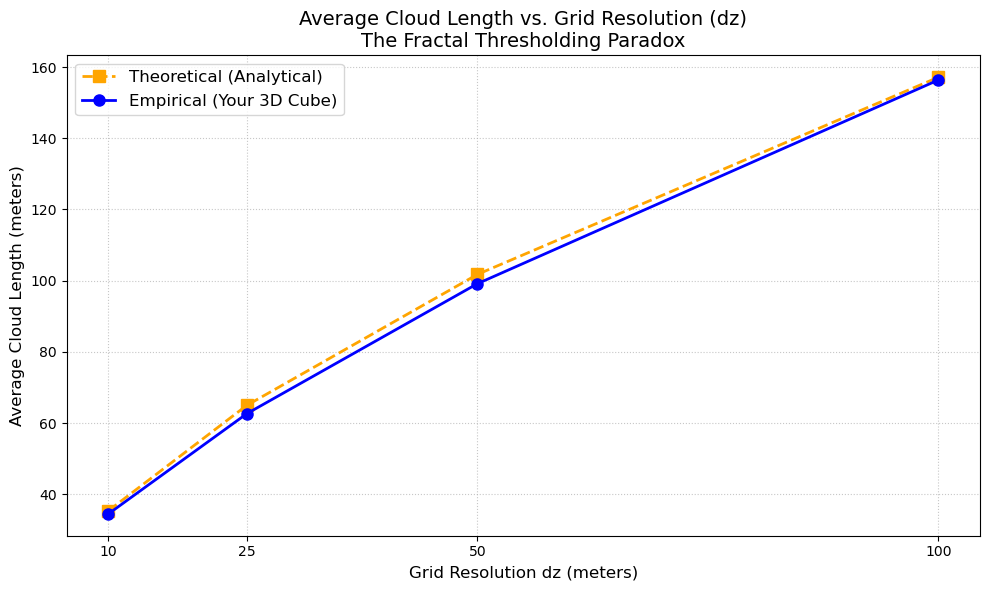

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- Your Fixed Parameters ---
L0 = 1000.0   
Lbox = 5000.0 
fraction = 0.08 

# The grid resolutions you want to test
dz_values = [10.0, 25.0, 50.0, 100.0]

actual_lengths = []
theoretical_lengths = []

print("Running 3D Simulations... this might take a moment.")

for dz in dz_values:
    # 1. Setup the grid for this specific dz
    N_grid = int(Lbox / dz)
    cc_ratio = np.full(N_grid, fraction)
    
    # 2. Generate your empirical cube
    cloud_cube = generate_cloud_cube(N_grid, Lbox, L0, cc_ratio)
    
    # 3. Calculate both lengths
    actual_L = calculate_empirical_chord_length(cloud_cube, dz, axis=0)[0]
    expected_L = analytical_cloud_length(L0, dz, Lbox, fraction)
    
    print(f"dz={dz:3.0f}m | Empirical: {actual_L:5.1f}m | Theoretical: {expected_L:5.1f}m")
    
    actual_lengths.append(actual_L)
    theoretical_lengths.append(expected_L)

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))

# Plot Theoretical line
plt.plot(dz_values, theoretical_lengths, 
         label='Theoretical (Analytical)', 
         marker='s', linestyle='--', color='orange', linewidth=2, markersize=8)

# Plot Empirical line
plt.plot(dz_values, actual_lengths, 
         label='Empirical (Your 3D Cube)', 
         marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)

plt.title('Average Cloud Length vs. Grid Resolution (dz)\nThe Fractal Thresholding Paradox', fontsize=14)
plt.xlabel('Grid Resolution dz (meters)', fontsize=12)
plt.ylabel('Average Cloud Length (meters)', fontsize=12)
plt.xticks(dz_values)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Generating 2D slices...


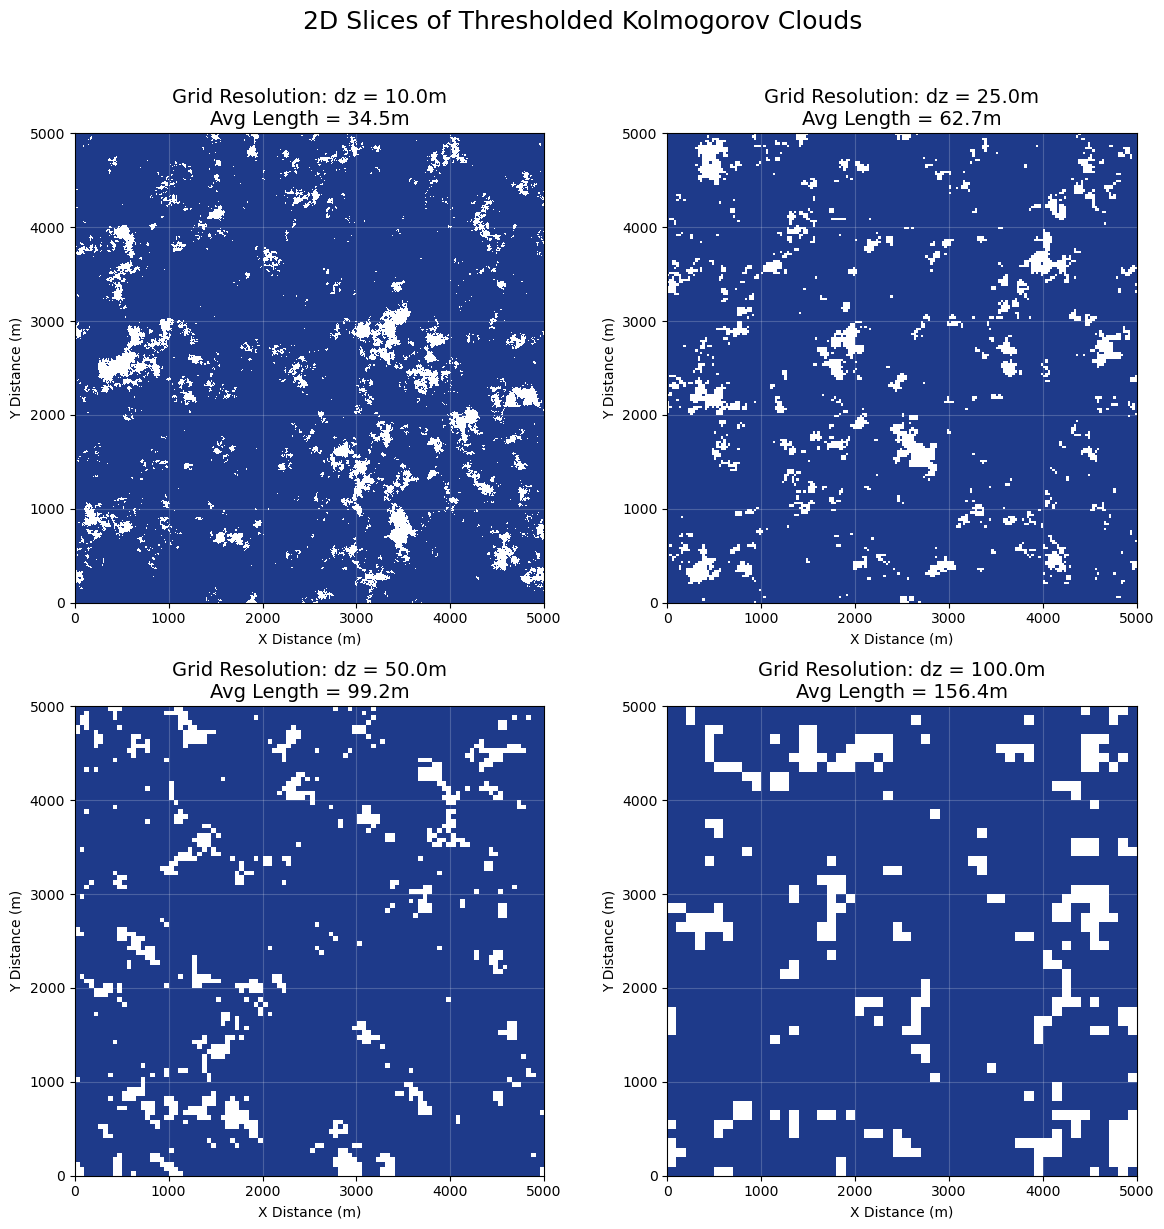

In [16]:

import matplotlib.colors as mcolors

# --- Your Fixed Parameters ---
L0 = 1000.0   
Lbox = 5000.0 
fraction = 0.08 
dz_values = [10.0, 25.0, 50.0, 100.0]

# Create a 2x2 figure grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten() # Flatten to easily loop over them

# Define a simple colormap: Clear sky = dark blue, Cloud = white
cmap_clouds = mcolors.ListedColormap(['#1E3A8A', 'white'])

print("Generating 2D slices...")

for i, dz in enumerate(dz_values):
    N_grid = int(Lbox / dz)
    cc_ratio = np.full(N_grid, fraction)
    
    # Generate your empirical 3D cube
    cloud_cube = generate_cloud_cube(N_grid, Lbox, L0, cc_ratio)
    
    # Extract a 2D slice right from the middle of the simulation box
    # Assuming your cube axes are (Z, Y, X), we take the middle Z-index
    mid_z_index = N_grid // 2
    slice_2d = cloud_cube[mid_z_index, :, :]
    
    # Calculate the empirical length for the title
    actual_L = calculate_empirical_chord_length(cloud_cube, dz, axis=0)[0]
    
    # Plot the 2D slice
    ax = axes[i]
    
    # We use extent=[0, Lbox, 0, Lbox] so the axes show actual physical meters, not pixel indices
    im = ax.imshow(slice_2d, cmap=cmap_clouds, origin='lower', 
                   extent=[0, Lbox, 0, Lbox], interpolation='none')
    
    ax.set_title(f"Grid Resolution: dz = {dz}m\nAvg Length = {actual_L:.1f}m", fontsize=14)
    ax.set_xlabel("X Distance (m)")
    ax.set_ylabel("Y Distance (m)")
    ax.grid(color='white', alpha=0.2)

plt.suptitle("2D Slices of Thresholded Kolmogorov Clouds", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [2]:
L0_array = np.arange(500, 5000, 100)

In [19]:
expected_L_array= np.zeros(len(L0_array))
for i,L in enumerate(L0_array):

    expected_L_array[i] = analytical_cloud_length(L, dz, Lbox, fraction)

/tmp/ipykernel_53389/80342025.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


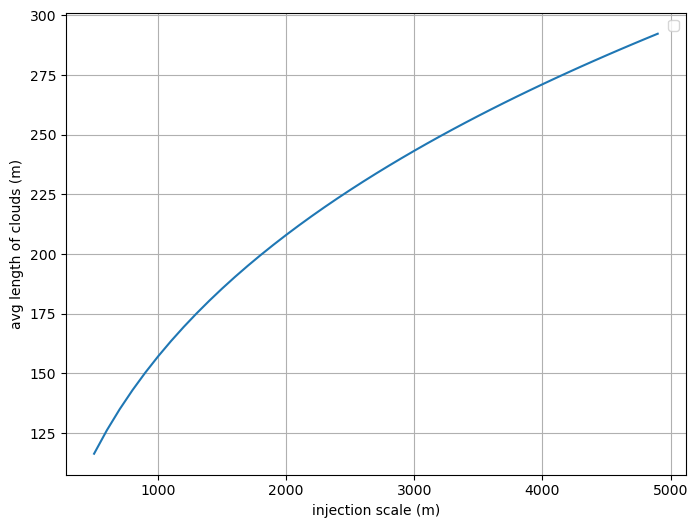

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(L0_array, expected_L_array)
plt.xlabel('injection scale (m)')
plt.ylabel('avg length of clouds (m)')
plt.legend()
plt.grid()
plt.show()

Let's make the cubes !

In [2]:
#for the 3D cube
import jax 
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
import numpy as np
import atmo3 as a3 
pi = np.pi

In [3]:
N_grid_cube = 128
beta= -11/3

Lbox = 1000 #m
L0_cube = 1000 #m

altitude_ground = 5100

# Initialize atmosphere
atmo = a3.Atmosphere(nside_grid=N_grid_cube, box_length_in_m=Lbox, site_altitude=altitude_ground)

# Define wavenumbers and power spectrum
dk = atmo.grid_wsp.dk
k = np.arange(N_grid) * dk
k0 = 2 * np.pi / L0_cube
k_tot = np.sqrt(k0**2 + k**2)
pofk = k_tot**beta
pspec = {'k': k, 'pofk': pofk}

NameError: name 'N_grid' is not defined

/tmp/ipykernel_53389/1442941641.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


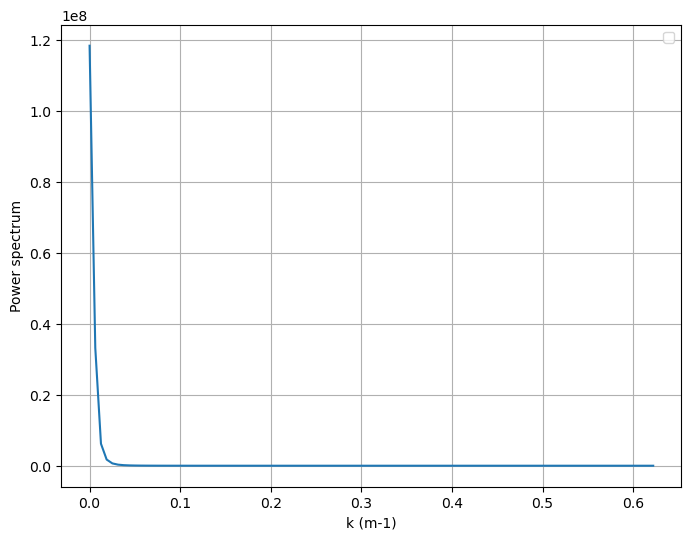

In [62]:
plt.figure(figsize=(8, 6))
plt.plot(k, pofk)
plt.xlabel('k (m-1)')
plt.ylabel('Power spectrum')
#plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [6]:

# --- Example Usage ---
L0 = 1000.0   # Injection scale m
dz = 50.0     #  meter resolution
Lbox = 5000.0 # size of the box in m
fraction = 0.08 # Threshold of the maximum perturbation

N_grid = int(Lbox/dz)

cc_ratio = np.full(N_grid, fraction)

cloud_cube = generate_cloud_cube (N_grid, Lbox, L0, cc_ratio)

In [ ]:
# Initialize atmosphere
atmo = a3.Atmosphere(nside_grid=N_grid, box_length_in_m=Lbox, site_altitude=altitude_ground)

seed =123456789

# Define wavenumbers and power spectrum
dk = atmo.grid_wsp.dk
k = np.arange(N_grid) * dk
k0 = 2 * np.pi / L0
k_tot = np.sqrt(k0**2 + k**2)
pofk = k_tot**beta
pspec = {'k': k, 'pofk': pofk}

# Rescaling factor for altitude
h_array = np.arange(N_grid) * atmo.grid_wsp.grid_spacing
h_scaling = np.ones_like(h_array)
rescale = {'h': h_array, 'f': h_scaling}

# Add component to atmosphere
field_name_v = 'clouds'
field_unit_v = 'no unit'

atmo.add_component(
    field_name=field_name_v,
    field_unit=field_unit_v,
    pspec=pspec,
    rescale=rescale,
    seed=seed,
)

# Generate realization
atmo.generate_realization(time_step=0)

# Extract 3D data and create cloud map based on cc_ratio
data_3d = atmo.components[field_name_v].field

    # 3. Create an empty 3D array of zeros to hold the final cloud map
cloud_cube = np.zeros_like(data_3d, dtype=int)

# 4. Loop through each horizontal slice (z-layer), we have a N_grid = N_z for the moment
for z in range(N_grid):
    layer_data = data_3d[:, :, z]
    ratio = cc_ratio[z]
    
    # If the ratio is practically 0, skip the math (layer remains all 0s)
    if ratio < 0.0001:
        continue
        
    # Calculate the percentile threshold for this specific layer
    threshold = np.percentile(layer_data, 100 * (1 - ratio))
    
    # Flag pixels above the threshold as 1 (cloud), everything else stays 0
    cloud_cube[:, :, z] = (layer_data >= threshold).astype(int)

return cloud_cube

In [ ]:
import numpy as np
from astropy import units as u
import pycraf.atm
from tqdm import tqdm  # Optional: Adds a progress bar for the long scan

# ==========================================
# 1. Parameter Setup & Physics Calculations
# ==========================================
Nx, Ny, Nz = cloud_cube.shape

# Base profiles from pycraf
altitudes_km = altitudes * u.m       
altitudes_km = altitudes_km.to(u.km) 

T_1d = pycraf.atm.profile_standard(altitudes_km)[0].value       # K
P_1d = pycraf.atm.profile_standard(altitudes_km)[1].value       # hPa
P_water_1d = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

# Cloud microphysics
rho_ice = 917.0 # kg/m^3
IWP = 1e-3      # kg/m^2
L_ice = Lbox / N_grid * N_pixels_with_clouds # m
r_eq = np.array([50e-6]) # m
frequency = np.array([150e9]) # Hz

# Calculate particle density 'n' BEFORE creating the n_ice array
n = IWP / (L_ice * (4/3) * np.pi * r_eq[0]**3 * rho_ice) # m^-3

# Create the 3D ice density cube
mask = (cloud_cube == 1)
n_ice = np.zeros((Nx, Ny, Nz))                                          
n_ice[mask] = n  # m^-3, only in cloud regions

# ==========================================
# 2. Projection en 3D (Broadcasting)
# ==========================================
T_3d = np.broadcast_to(T_1d.reshape(1, 1, Nz), (Nx, Ny, Nz)).copy()
P_3d = np.broadcast_to(P_1d.reshape(1, 1, Nz), (Nx, Ny, Nz)).copy()
P_water_3d = np.broadcast_to(P_water_1d.reshape(1, 1, Nz), (Nx, Ny, Nz)).copy()

In [7]:
import numpy as np

def calculate_relative_humidity(p, T, q):
    """
    Calculates the mixed water/ice relative humidity.
    
    Parameters:
    -----------
    p : array_like
        Atmospheric pressure in Pascals (Pa).
    T : array_like
        Temperature in Kelvin (K).
    q : array_like
        Specific humidity in kg/kg.
        
    Returns:
    --------
    rh : ndarray
        Relative humidity in percent (%).
    """
    # Convert inputs to numpy arrays
    p = np.asarray(p)
    T = np.asarray(T)
    q = np.asarray(q)
    
    # Constants
    epsilon = 0.621981
    T_0 = 273.16    # K
    T_ice = 250.16  # K
    
    # Tetens formula parameters for water (Buck 1981)
    a1_w = 611.21   # Pa
    a3_w = 17.502
    a4_w = 32.19    # K
    
    # Tetens formula parameters for ice (Alduchov and Eskridge 1996)
    a1_i = 611.21   # Pa
    a3_i = 22.587
    a4_i = -0.7     # K

    # 1. Calculate the mixed-phase parameter (alpha) [Eq. 7.94]
    alpha = np.zeros_like(T)
    
    # T >= T_0 (Liquid water phase)
    alpha[T >= T_0] = 1.0
    
    # T_ice < T < T_0 (Mixed phase)
    mask_mixed = (T > T_ice) & (T < T_0)
    alpha[mask_mixed] = ((T[mask_mixed] - T_ice) / (T_0 - T_ice)) ** 2
    
    # T <= T_ice (Ice phase, remains 0.0 as initialized)
    
    # 2. Calculate saturation partial pressure with respect to water and ice [Eq. 7.93]
    e_sat_w = a1_w * np.exp(a3_w * ((T - T_0) / (T - a4_w)))
    e_sat_i = a1_i * np.exp(a3_i * ((T - T_0) / (T - a4_i)))
    
    # 3. Calculate total saturation vapour pressure [Eq. 7.92]
    e_sat = alpha * e_sat_w + (1 - alpha) * e_sat_i
    
    # 4. Calculate partial pressure of water vapour (e)
    # Extracted from the numerator/denominator of Eq. 7.91
    e = (p * q / epsilon) / (1 + q * ((1 / epsilon) - 1))
    
    # 5. Calculate Relative Humidity (%) [Eq. 7.91]
    rh = 100.0 * (e / e_sat)
    
    return rh

In [8]:
import numpy as np
import numpy as np
from astropy import units as u
import pycraf.atm

# --- Example Usage ---
L0 = 1000.0   # Injection scale m
dz = 50.0     #  meter resolution
Lbox = 5000.0 # size of the box in m
fraction = 0.08 # Threshold of the maximum perturbation

N_grid = int(Lbox/dz)

cc_ratio = np.full(N_grid, fraction)

#cloud_cube = generate_cloud_cube (N_grid, Lbox, L0, cc_ratio)

# 1. Initialize your atmosphere
my_atm = a3.Atmosphere(nside_grid=N_grid, box_length_in_m=Lbox, site_altitude=5100.0)


In [9]:
# 2. Define your 1D layer-by-layer profile
altitudes_m = np.linspace(5100, 7000, N_grid+1)       # Example heights
temperatures_K = np.geomspace(70, 0.1, N_grid+1) +220 # Example temperatures

# 3. Add the property using the exact dictionary structure atmo3 expects
my_atm.add_property(
    property_name='temperature',
    property_unit='K',
    property_value={
        'h': altitudes_m,
        'f': temperatures_K
    }
)

# Project the 1D property into a 3D JAX array
temperature_3d_grid = my_atm.grid_wsp.interp2grid(
    my_atm.properties['temperature']['value']['h'], 
    my_atm.properties['temperature']['value']['f']
)

print(temperature_3d_grid.shape) # Will output (128, 128, 128)

(100, 100, 100)


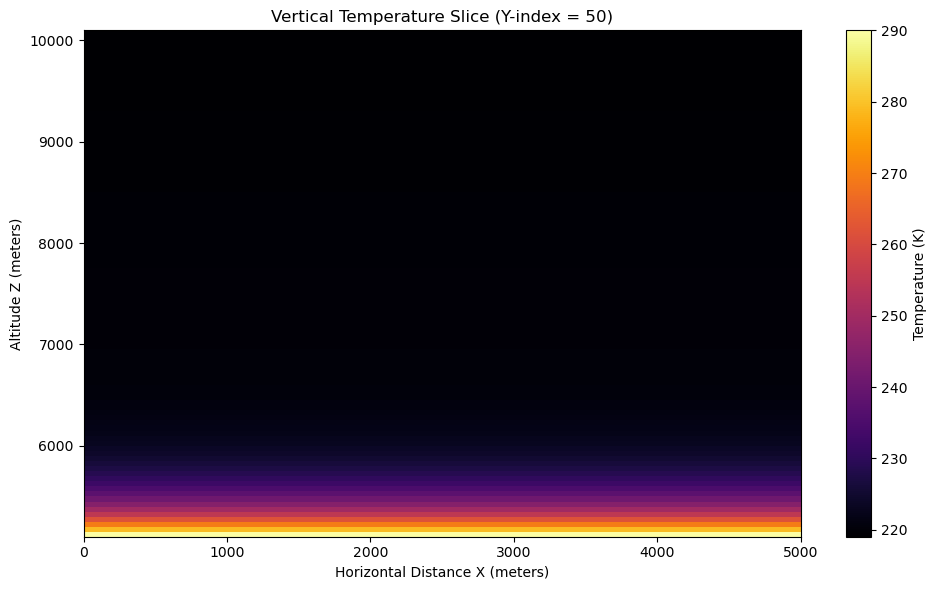

In [10]:
import numpy as np
import matplotlib.pyplot as plt

site_altitude = 5100
# ==========================================
# 1. Grid Parameters (from your atmo3 setup)
# ==========================================
# Assuming these variables are already defined in your code:
# temperature_3d_grid (shape: Nx, Ny, Nz)
# Lbox (horizontal length in meters, e.g., 10000.0)
# dz (vertical layer thickness in meters)
# site_altitude (starting altitude in meters, e.g., 0.0)

Nx, Ny, Nz = temperature_3d_grid.shape

# ==========================================
# 2. Extract the Slice
# ==========================================
# Choose a slice along the Y-axis (let's cut right through the middle)
y_index = Ny // 2

# Extract the 2D slice: shape becomes (Nx, Nz)
temp_slice = temperature_3d_grid[:, y_index, :]

# Transpose it so Z (altitude) is on the vertical axis and X is on the horizontal
temp_slice_plot = temp_slice.T 

# ==========================================
# 3. Calculate Physical Axes
# ==========================================
# Calculate the maximum altitude using your dz
max_altitude = site_altitude + (Nz * dz)

# The 'extent' parameter maps the array indices to physical coordinates
# Format: [x_min, x_max, z_min, z_max]
physical_extent = [0, Lbox, site_altitude, max_altitude]

# ==========================================
# 4. Plot the Slice
# ==========================================
plt.figure(figsize=(10, 6))

# Use aspect='auto' so the plot fills the figure nicely, 
# otherwise imshow tries to force 1 meter X to equal 1 meter Z visually
im = plt.imshow(
    temp_slice_plot, 
    cmap='inferno',       # 'inferno' is standard/beautiful for temperature data
    origin='lower',       # Critical: Ensures the ground (lowest Z) is at the bottom
    extent=physical_extent, 
    aspect='auto'         
)

plt.title(f"Vertical Temperature Slice (Y-index = {y_index})")
plt.xlabel("Horizontal Distance X (meters)")
plt.ylabel("Altitude Z (meters)")

cbar = plt.colorbar(im)
cbar.set_label("Temperature (K)")

plt.tight_layout()
plt.show()

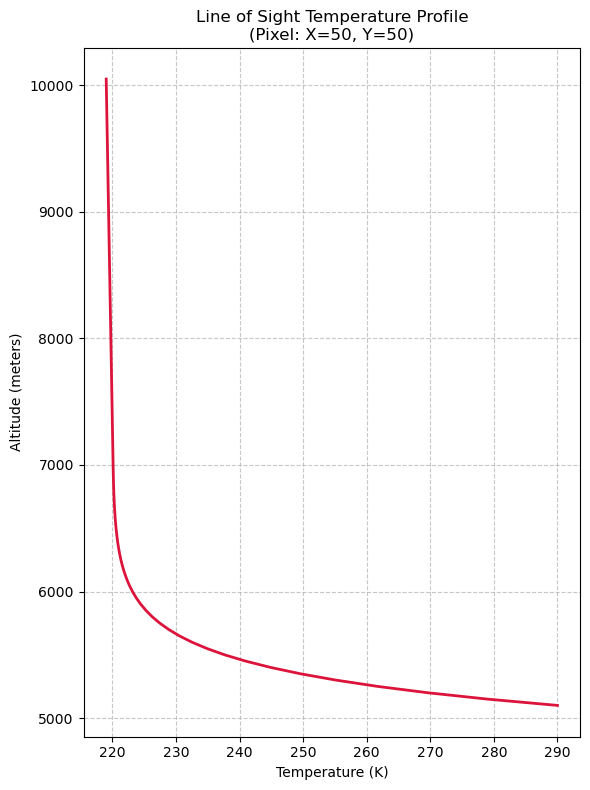

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Grid Parameters
# ==========================================
# Assuming these are already defined:
# temperature_3d_grid (shape: Nx, Ny, Nz)
# dz (vertical layer thickness in meters)
# site_altitude (starting altitude in meters)

Nx, Ny, Nz = temperature_3d_grid.shape

# ==========================================
# 2. Extract the Line of Sight (90° Elevation)
# ==========================================
# Pick the specific pixel (x, y) you want to look above. 
# Let's pick the exact center of your map:
x_index = Nx // 2
y_index = Ny // 2

# Extract the 1D profile. The shape of this will be (Nz,)
# The ':' tells NumPy to grab every single layer along the Z-axis for this pixel
los_temperature = temperature_3d_grid[x_index, y_index, :]

# ==========================================
# 3. Create the Altitude Axis
# ==========================================
# Generate an array of the exact physical altitudes for each layer
# np.arange(Nz) creates [0, 1, 2, ... Nz-1]
altitudes = site_altitude + (np.arange(Nz) * dz)

# ==========================================
# 4. Plot the Vertical Profile
# ==========================================
plt.figure(figsize=(6, 8))

# Plot Temperature on X, Altitude on Y
plt.plot(los_temperature, altitudes, color='crimson', linewidth=2)

plt.title(f"Line of Sight Temperature Profile\n(Pixel: X={x_index}, Y={y_index})")
plt.xlabel("Temperature (K)")
plt.ylabel("Altitude (meters)")

# Optional: Add a grid to make reading values easier
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:

# --- Example Usage ---
L0 = 500.0   # Injection scale m
dz = 50.0     #  meter resolution
Lbox = 5000.0 # size of the box in m
fraction = 0.08 # Threshold of the maximum perturbation

N_grid = int(Lbox/dz)

cc_ratio = np.full(N_grid, fraction)
UTC_hour = 15
altitude_ground = 5100
beta = -11/3
seed = 123456789

In [12]:
# Initialize atmosphere
atmo = a3.Atmosphere(nside_grid=N_grid, box_length_in_m=Lbox, site_altitude=altitude_ground)

# Define wavenumbers and power spectrum
dk = atmo.grid_wsp.dk
k = np.arange(N_grid) * dk
k0 = 2 * np.pi / L0
k_tot = np.sqrt(k0**2 + k**2)
pofk = k_tot**beta
pofk/= np.max(pofk)
pspec = {'k': k, 'pofk': pofk}



delta_q_profile = np.load('/pscratch/sd/v/valer/atmo3/examples/delta_q_profiles_2023_07.npz')['delta_q_map'] #  kg/kg

mean_q_profile = np.load('/pscratch/sd/v/valer/atmo3/examples/mean_q_profiles_2023_07.npz')['typical_profiles'] #  kg/kg

altitude = np.load('/pscratch/sd/v/valer/atmo3/examples/delta_q_profiles_2023_07.npz')['alt_grid']

rescale = {'h': altitude, 'f': delta_q_profile[UTC_hour]}

mean_q = mean_q_profile[UTC_hour]
delta_q = delta_q_profile[UTC_hour]


# Add component to atmosphere
field_name_v = 'specific humidity q variations'
field_unit_v = 'kg/kg'

atmo.add_component(
    field_name=field_name_v,
    field_unit=field_unit_v,
    pspec=pspec,
    rescale=rescale,
    seed=seed,
    #mean=mean_q
)



# Generate realization

In [13]:
atmo.generate_realization(time_step=0, component_name=field_name_v)

# Extract your final 3D JAX arrays
q_variations_cube = atmo.components[field_name_v].field

In [14]:

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

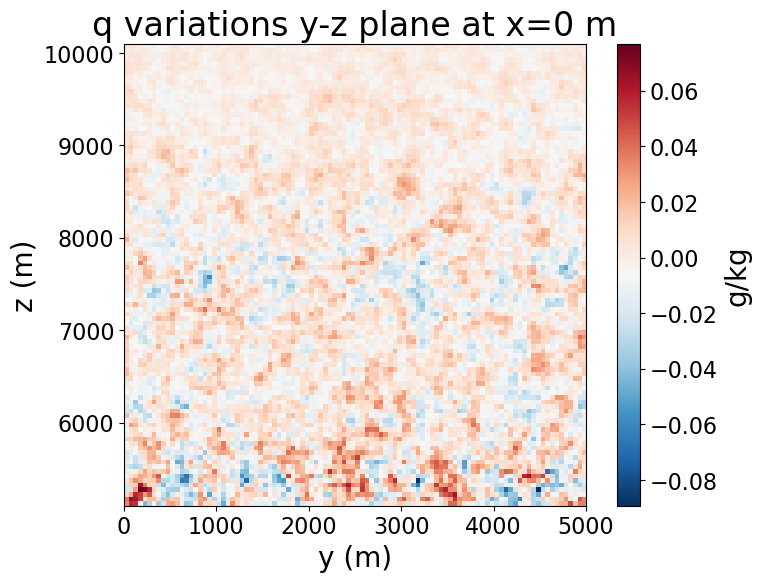

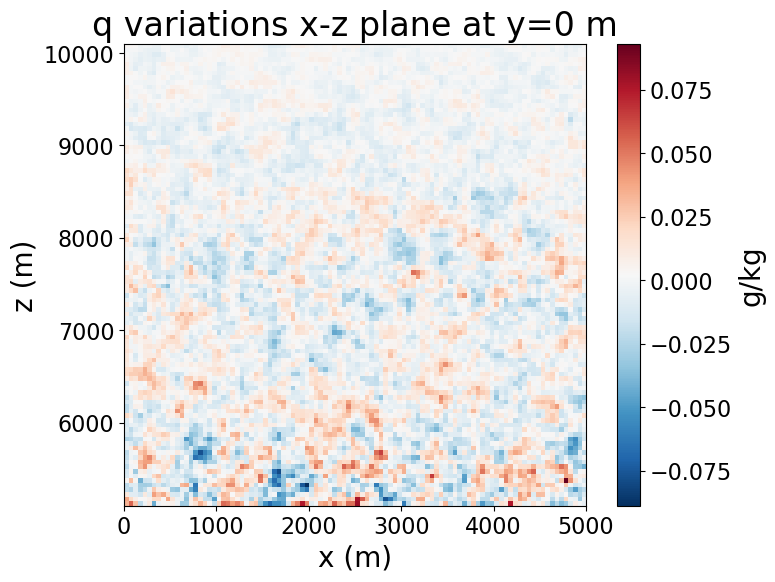

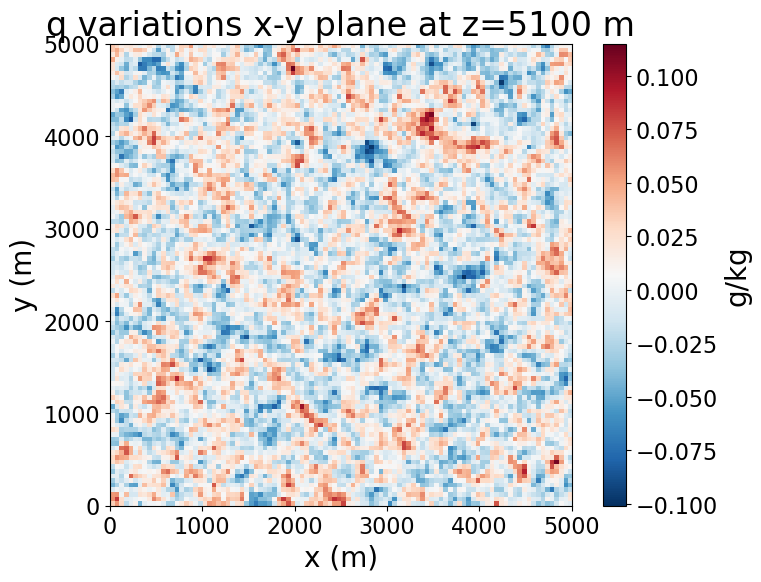

In [15]:
import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    q_variations_cube[0, :, :].T*1e3,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower',
     # vmin=-0.01, vmax=0.01
)
plt.colorbar(label= "g/kg")
plt.title(f"q variations y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 2. X-Z Plane (at y = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    q_variations_cube[:, 0, :].T*1e3,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="g/kg")
plt.title(f"q variations x-z plane at y=0 m")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 3. X-Y Plane (at z = site_altitude)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    q_variations_cube[:, :, 0].T*1e3,
    extent=(0, Lbox, 0, Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="g/kg")
plt.title(f"q variations x-y plane at z={site_altitude} m")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_928054/4140640475.py:24: SyntaxWarning: invalid escape sequence '\p'
  label='$\pm 1 \Delta q$'


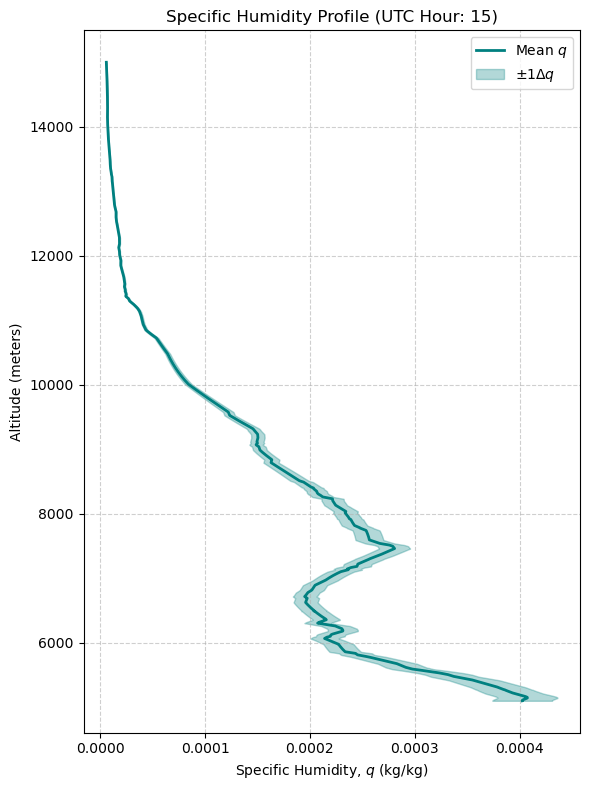

In [17]:
import matplotlib.pyplot as plt
# ==========================================
# 1. Plot Setup
# ==========================================
plt.figure(figsize=(6, 8))

# ==========================================
# 2. Plot the Mean Curve
# ==========================================
# We plot q on the X-axis and altitude on the Y-axis
plt.plot(mean_q, altitude, color='teal', linewidth=2, label='Mean $q$')

# ==========================================
# 3. Add the Shaded Delta Region
# ==========================================
# fill_betweenx needs: (y-axis data, x-min bound, x-max bound)
# alpha=0.3 makes the shading 70% transparent so it looks nice and doesn't overpower the line
plt.fill_betweenx(
    altitude, 
    mean_q - delta_q, 
    mean_q + delta_q, 
    color='teal', 
    alpha=0.3, 
    label='$\pm 1 \Delta q$'
)

# ==========================================
# 4. Formatting
# ==========================================
plt.title(f"Specific Humidity Profile (UTC Hour: {UTC_hour})")
plt.xlabel("Specific Humidity, $q$ (kg/kg)")
plt.ylabel("Altitude (meters)")

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the legend
plt.legend()

plt.tight_layout()
plt.show()

Let's add some properties for our cube ! ie cube of T, P and q

In [10]:
print(test)

NpzFile '/pscratch/sd/v/valer/atmo3/examples/mean_q_profiles_2023_07.npz' with keys: typical_profiles, alt_grid


In [16]:
altitudes_km = altitude * u.m       
altitudes_km = altitudes_km.to(u.km) 

T_1d = pycraf.atm.profile_standard(altitudes_km)[0].value       # K
P_1d = pycraf.atm.profile_standard(altitudes_km)[1].value       # hPa
P_water_1d = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

In [17]:
# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='temperature',
    property_unit='K',
    property_value={
        'h': altitude,
        'f': T_1d
    }
)

# Project the 1D property into a 3D JAX array
temperature_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['temperature']['value']['h'], 
    atmo.properties['temperature']['value']['f']
)

# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='specific humidity',
    property_unit='kg/kg',
    property_value={
        'h': altitude,
        'f': mean_q
    }
)

# Project the 1D property into a 3D JAX array
q_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['specific humidity']['value']['h'], 
    atmo.properties['specific humidity']['value']['f']
)

# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='pressure',
    property_unit='hPa',
    property_value={
        'h': altitude,
        'f': P_1d
    }
)

# Project the 1D property into a 3D JAX array
P_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['pressure']['value']['h'], 
    atmo.properties['pressure']['value']['f']
)


In [18]:
import numpy as np

def calculate_relative_humidity(p, T, q):
    """
    Calculates the mixed water/ice relative humidity.
    
    Parameters:
    -----------
    p : array_like
        Atmospheric pressure in Pascals (Pa).
    T : array_like
        Temperature in Kelvin (K).
    q : array_like
        Specific humidity in kg/kg.
        
    Returns:
    --------
    rh : ndarray
        Relative humidity in percent (%).
    """
    # Convert inputs to numpy arrays
    p = np.asarray(p)
    T = np.asarray(T)
    q = np.asarray(q)
    
    # Constants
    epsilon = 0.621981
    T_0 = 273.16    # K
    T_ice = 250.16  # K
    
    # Tetens formula parameters for water (Buck 1981)
    a1_w = 611.21   # Pa
    a3_w = 17.502
    a4_w = 32.19    # K
    
    # Tetens formula parameters for ice (Alduchov and Eskridge 1996)
    a1_i = 611.21   # Pa
    a3_i = 22.587
    a4_i = -0.7     # K

    # 1. Calculate the mixed-phase parameter (alpha) [Eq. 7.94]
    alpha = np.zeros_like(T)
    
    # T >= T_0 (Liquid water phase)
    alpha[T >= T_0] = 1.0
    
    # T_ice < T < T_0 (Mixed phase)
    mask_mixed = (T > T_ice) & (T < T_0)
    alpha[mask_mixed] = ((T[mask_mixed] - T_ice) / (T_0 - T_ice)) ** 2
    
    # T <= T_ice (Ice phase, remains 0.0 as initialized)
    
    # 2. Calculate saturation partial pressure with respect to water and ice [Eq. 7.93]
    e_sat_w = a1_w * np.exp(a3_w * ((T - T_0) / (T - a4_w)))
    e_sat_i = a1_i * np.exp(a3_i * ((T - T_0) / (T - a4_i)))
    
    # 3. Calculate total saturation vapour pressure [Eq. 7.92]
    e_sat = alpha * e_sat_w + (1 - alpha) * e_sat_i
    
    # 4. Calculate partial pressure of water vapour (e)
    # Extracted from the numerator/denominator of Eq. 7.91
    e = (p * q / epsilon) / (1 + q * ((1 / epsilon) - 1))
    
    # 5. Calculate Relative Humidity (%) [Eq. 7.91]
    rh = 100.0 * (e / e_sat)
    
    return rh

In [19]:
rh_3d_grid = calculate_relative_humidity(P_3d_grid, temperature_3d_grid, q_3d_grid)

In [20]:
delta_rh_3d_grid = calculate_relative_humidity(P_3d_grid, temperature_3d_grid, q_variations_cube)

In [21]:
full_rh_3d_grid = calculate_relative_humidity(P_3d_grid, temperature_3d_grid, q_variations_cube+q_3d_grid)

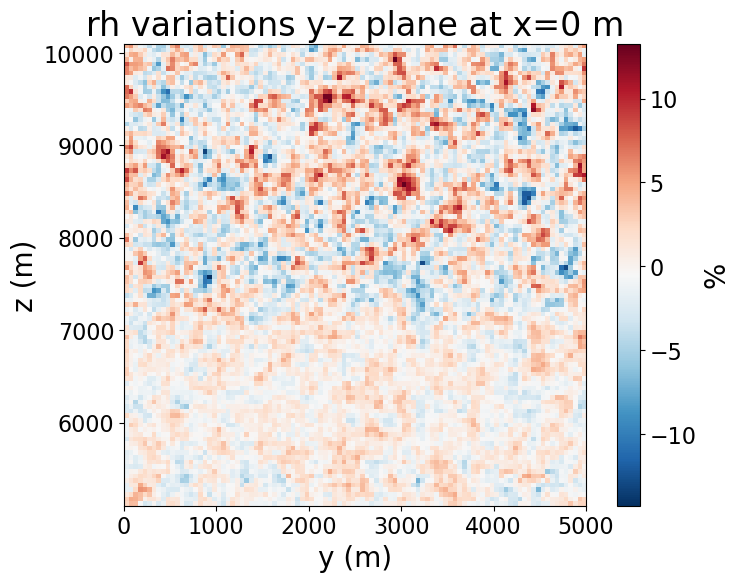

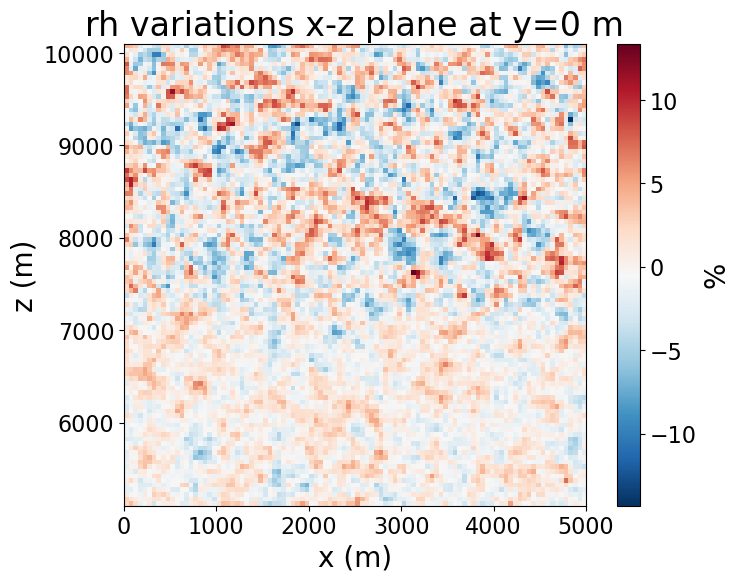

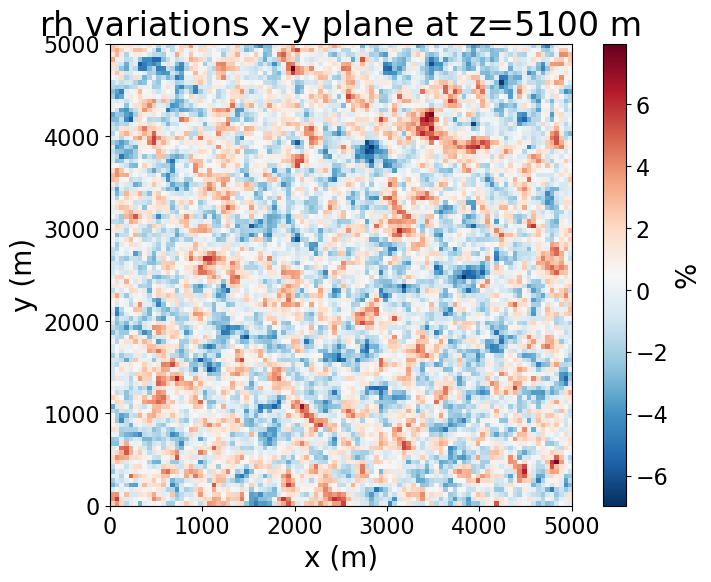

In [22]:
import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    delta_rh_3d_grid[0, :, :].T*100,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label= "%")
plt.title(f"rh variations y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 2. X-Z Plane (at y = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    delta_rh_3d_grid[:, 0, :].T*100,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="%")
plt.title(f"rh variations x-z plane at y=0 m")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 3. X-Y Plane (at z = site_altitude)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    delta_rh_3d_grid[:, :, 0].T*100,
    extent=(0, Lbox, 0, Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="%")
plt.title(f"rh variations x-y plane at z={site_altitude} m")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

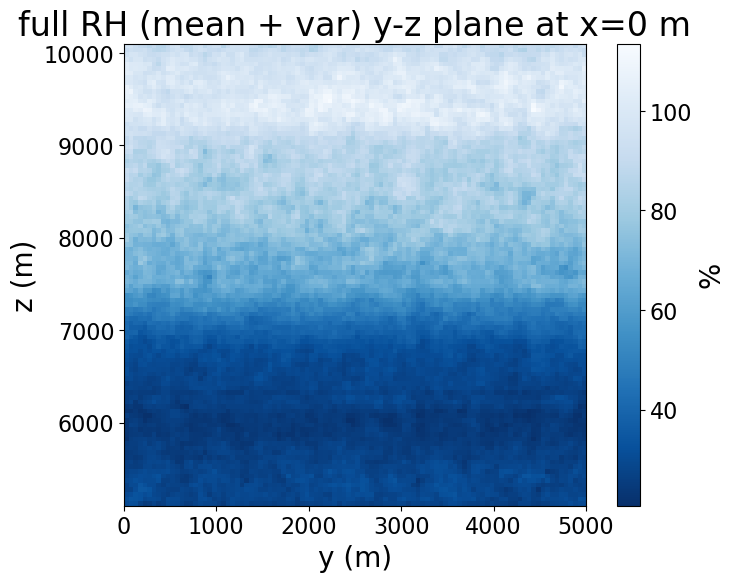

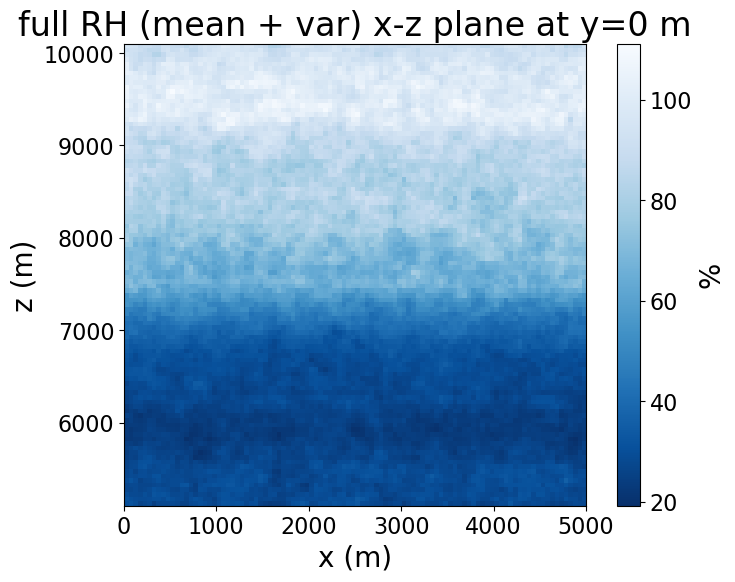

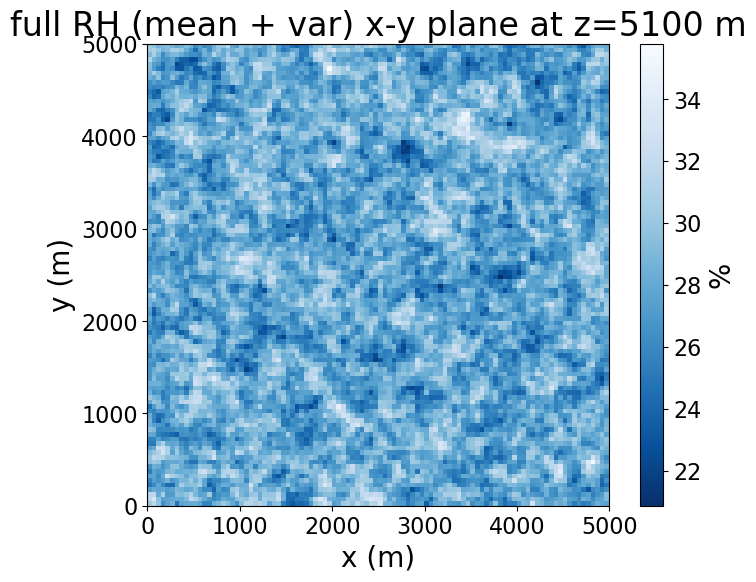

In [25]:
import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    full_rh_3d_grid[0, :, :].T*100,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='Blues_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label= "%")
plt.title(f"full RH (mean + var) y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 2. X-Z Plane (at y = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    full_rh_3d_grid[:, 0, :].T*100,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='Blues_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="%")
plt.title(f"full RH (mean + var) x-z plane at y=0 m")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 3. X-Y Plane (at z = site_altitude)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    full_rh_3d_grid[:, :, 0].T*100,
    extent=(0, Lbox, 0, Lbox),
    cmap='Blues_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="%")
plt.title(f"full RH (mean + var) x-y plane at z={site_altitude} m")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

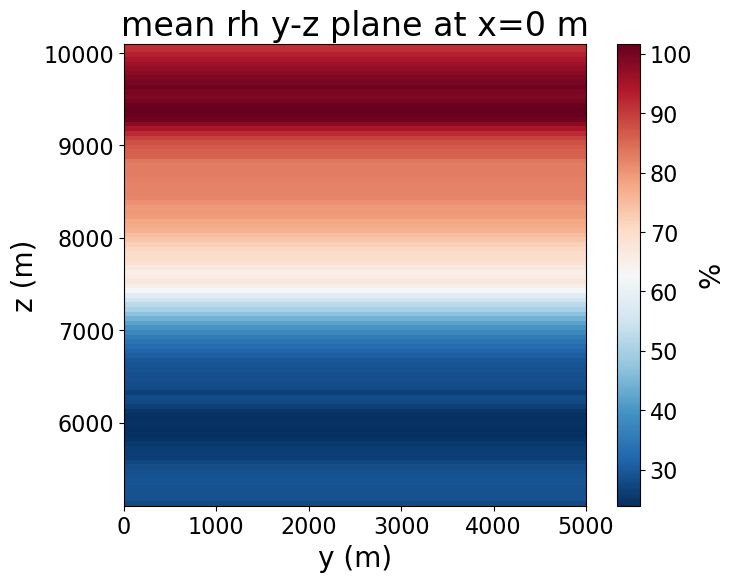

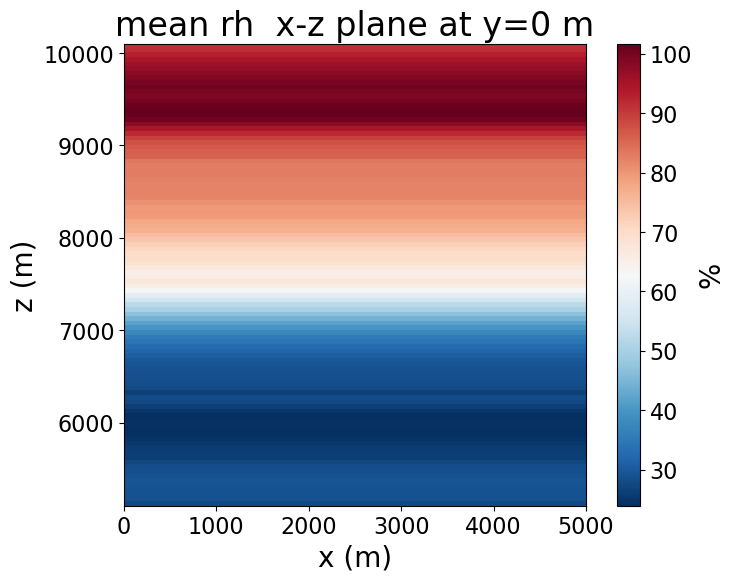

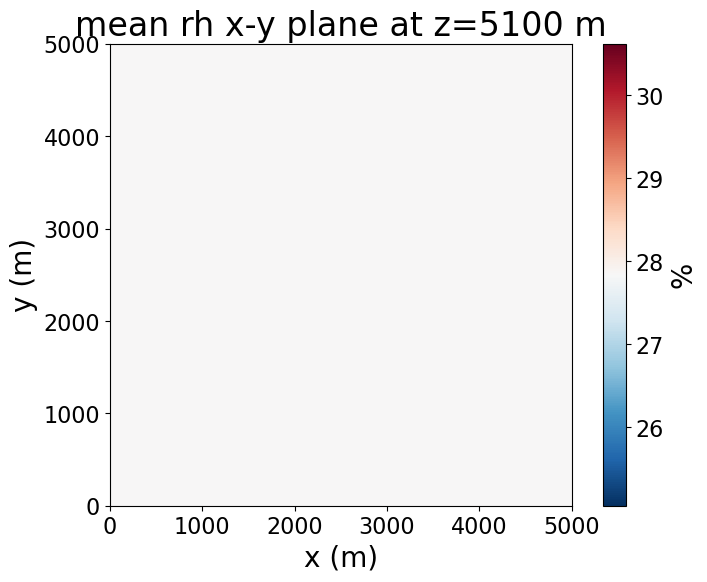

In [55]:
import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    rh_3d_grid[0, :, :].T*100,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label= "%")
plt.title(f"mean rh y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 2. X-Z Plane (at y = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    rh_3d_grid[:, 0, :].T*100,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="%")
plt.title(f"mean rh  x-z plane at y=0 m")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 3. X-Y Plane (at z = site_altitude)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    rh_3d_grid[:, :, 0].T*100,
    extent=(0, Lbox, 0, Lbox),
    cmap='RdBu_r', origin='lower', 
    #vmin=-0.01, vmax=0.01
)
plt.colorbar(label="%")
plt.title(f"mean rh x-y plane at z={site_altitude} m")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

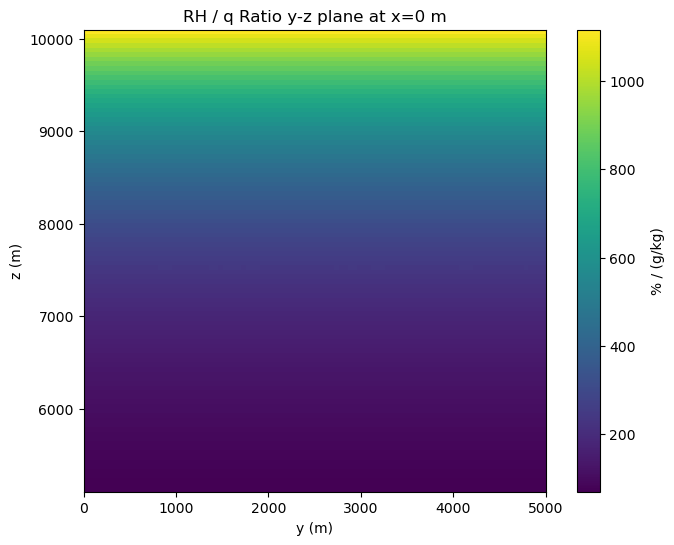

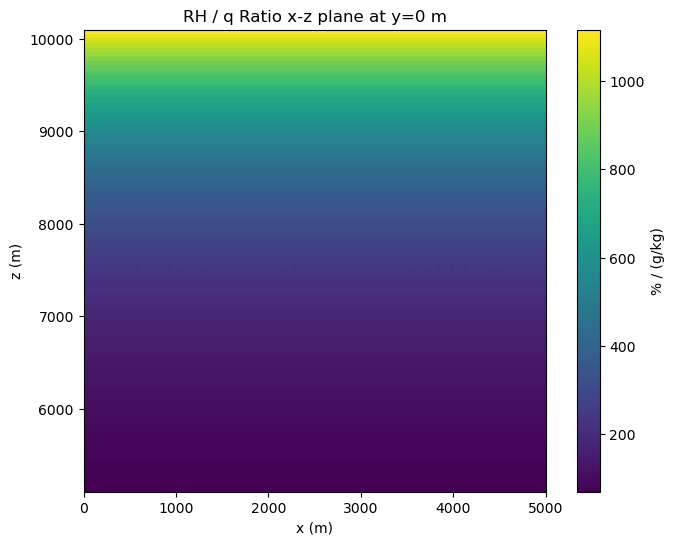

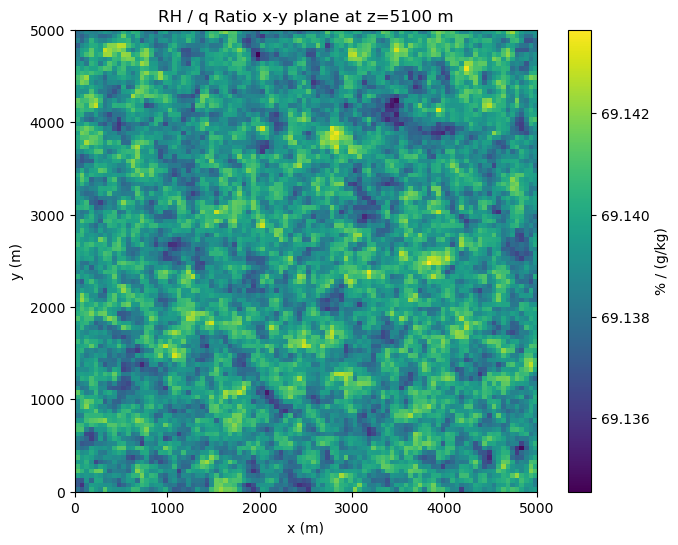

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. Safely Calculate the Ratio Cube
# ==========================================
# Convert to the units you used in your plots (% and g/kg)
rh_percent_cube = delta_rh_3d_grid * 100.0
q_g_kg_cube = q_variations_cube * 1e3

# Safely divide: If q is 0, assign NaN to avoid a crash/infinity
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_cube = np.where(
        np.abs(q_g_kg_cube) > 1e-10, # Check if q is safely above zero
        rh_percent_cube / q_g_kg_cube, 
        np.nan
    )

ratio_unit = "% / (g/kg)"
site_altitude = altitude_ground

# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
im = plt.imshow(
    ratio_cube[0, :, :].T,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='viridis', origin='lower' # 'viridis' is great for positive sequential data
)
plt.colorbar(im, label=ratio_unit)
plt.title(f"RH / q Ratio y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 2. X-Z Plane (at y = 0)
# ==========================================
plt.figure(figsize=(8, 6))
im = plt.imshow(
    ratio_cube[:, 0, :].T,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='viridis', origin='lower'
)
plt.colorbar(im, label=ratio_unit)
plt.title(f"RH / q Ratio x-z plane at y=0 m")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 3. X-Y Plane (at z = site_altitude)
# ==========================================
plt.figure(figsize=(8, 6))
im = plt.imshow(
    ratio_cube[:, :, 0].T,
    extent=(0, Lbox, 0, Lbox),
    cmap='viridis', origin='lower'
)
plt.colorbar(im, label=ratio_unit)
plt.title(f"RH / q Ratio x-y plane at z={site_altitude} m")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()